# The Mechanics of Convolution: From Arithmetic to Vision 👁️

Welcome to a deep dive into the engine of Computer Vision.

In this notebook, we will **not** train a model on a massive dataset yet. Instead, we will open up the "black box" of a Convolutional Layer to understand exactly what happens to the numbers.

**We will explore:**
1.  **The Math of Convolution:** How a sliding window turns a matrix of numbers into a feature map.
2.  **Hyperparameters:** The impact of **Kernel Size**, **Stride**, and **Padding** (visualized on $8 \times 8$ grids).
3.  **The Backward Pass (Theory):** How the network accumulates errors to update the filter weights (Gradient Accumulation).
4.  **Real World Filters:** Applying manual filters (Edge Detection, Blur) to a real image.
5.  **Color Convolution:** A sneak peek into how we handle RGB images.

---

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision
import torchvision.transforms as transforms

# Setup visualization settings
plt.rcParams['figure.figsize'] = (12, 6)
torch.manual_seed(42)
np.random.seed(42)

print("✅ Ready to explore Convolutions.")

✅ Ready to explore Convolutions.


## 1. The Micro-Level: $8 \times 8$ Grid 🔬

Images are just matrices of numbers. To understand convolution, let's start with a tiny synthetic image ($8 \times 8$ pixels).

We will create a simple pattern: A bright vertical line in a dark background.

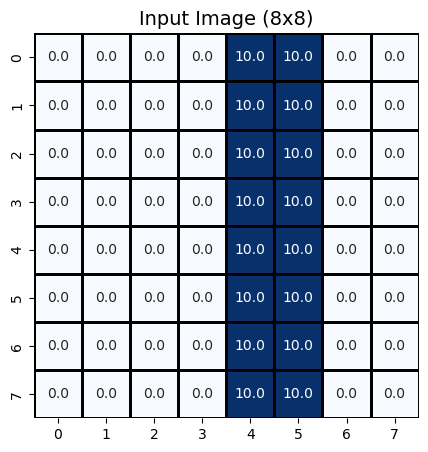

In [4]:
def plot_matrix(tensor, title="Matrix", cmap="Blues", annot=True):
    # Helper function to visualize small tensors
    matrix = tensor.squeeze().numpy()
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=annot, fmt=".1f", cmap=cmap, cbar=False, 
                linewidths=1, linecolor='black', square=True)
    plt.title(title, fontsize=14)
    plt.show()

# Create a synthetic 8x8 image
# Background = 0 (Dark)
# Vertical Line at index 4 = 10 (Bright)
input_grid = torch.zeros(8, 8)
input_grid[:, 4] = 10.0  
input_grid[:, 5] = 10.0

plot_matrix(input_grid, title="Input Image (8x8)")

### 1.1 The Kernel (Filter)

A **Kernel** is a small matrix (weights) that "scans" the image. It looks for specific patterns.

Let's create a **Vertical Edge Detector** ($3 \times 3$).
* Left column: $-1$
* Middle column: $0$
* Right column: $+1$

If this filter scans a uniform area (all zeros), the result is $0$. 
If it hits a vertical line (transition from 0 to 10), the math will produce a high number.

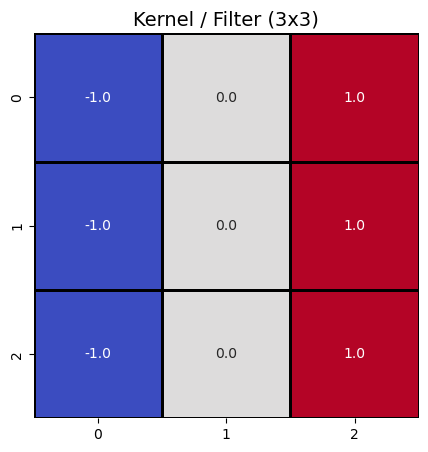

In [5]:
kernel = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0]
])

plot_matrix(kernel, title="Kernel / Filter (3x3)", cmap="coolwarm")

### 1.2 The Dot Product (Sliding Window)

The convolution operation is simple: **Multiply and Sum**.

For every position of the kernel on the image:
1.  Overlay the $3 \times 3$ kernel on a $3 \times 3$ patch of the image.
2.  Multiply overlapping numbers element-wise.
3.  Sum up all the results.
4.  This sum becomes **one pixel** in the Output Feature Map.

$$ Output_{x,y} = \sum \sum (Image_{patch} * Kernel) $$

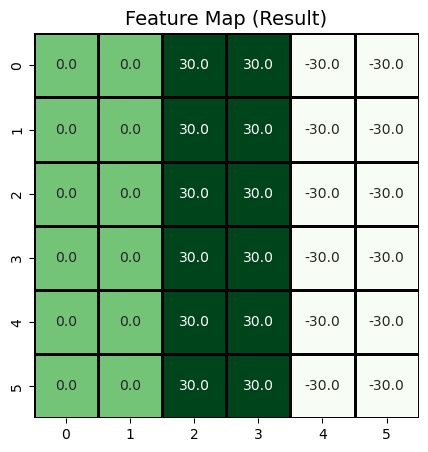

In [7]:
# Let's perform convolution using PyTorch's functional API
# PyTorch expects 4D tensors: [Batch, Channels, Height, Width]

input_batch = input_grid.unsqueeze(0).unsqueeze(0) # Shape: [1, 1, 8, 8]
kernel_batch = kernel.unsqueeze(0).unsqueeze(0)    # Shape: [1, 1, 3, 3]

output_map = F.conv2d(input_batch, kernel_batch, stride=1, padding=0)

plot_matrix(output_map, title="Feature Map (Result)", cmap="Greens")

**Observation:**
Notice the output size is $6 \times 6$. Why? Because we can't place a $3 \times 3$ kernel on the very edge of an $8 \times 8$ image without going out of bounds (unless we use Padding).

## 2. Hyperparameters: Stride & Padding 🎛️

We don't just slide the window pixel-by-pixel. We can control the movement.

### 2.1 Stride (The Step Size)
**Stride** controls how many pixels we skip after each calculation.
* **Stride = 1:** High detail, slow (output size roughly same as input).
* **Stride = 2:** Skips every other pixel. Output size is halved (Downsampling).

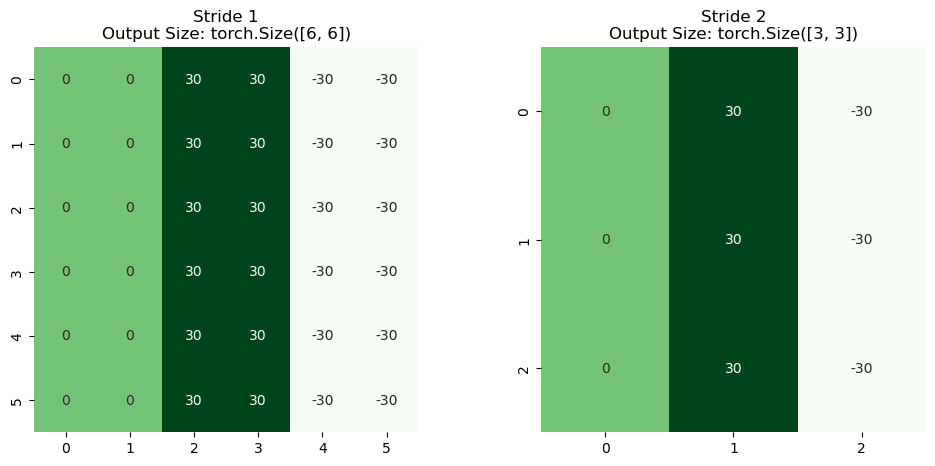

In [8]:
# Stride = 1
out_stride_1 = F.conv2d(input_batch, kernel_batch, stride=1, padding=0)

# Stride = 2
out_stride_2 = F.conv2d(input_batch, kernel_batch, stride=2, padding=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Stride 1
sns.heatmap(out_stride_1.squeeze(), annot=True, fmt=".0f", cmap="Greens", cbar=False, ax=axes[0], square=True)
axes[0].set_title(f"Stride 1\nOutput Size: {out_stride_1.shape[-2:]}")

# Plot Stride 2
sns.heatmap(out_stride_2.squeeze(), annot=True, fmt=".0f", cmap="Greens", cbar=False, ax=axes[1], square=True)
axes[1].set_title(f"Stride 2\nOutput Size: {out_stride_2.shape[-2:]}")

plt.show()

### 2.2 Padding (The Frame)

Notice how our $8 \times 8$ image became $6 \times 6$? We lost the borders!
To keep the size constant, we use **Padding**. We add a border of Zeros around the input.

* **Padding = 0 (Valid):** No padding. Output shrinks.
* **Padding = 1 (Same):** Adds 1 pixel border. Output size stays $8 \times 8$ (for $3 \times 3$ kernel).

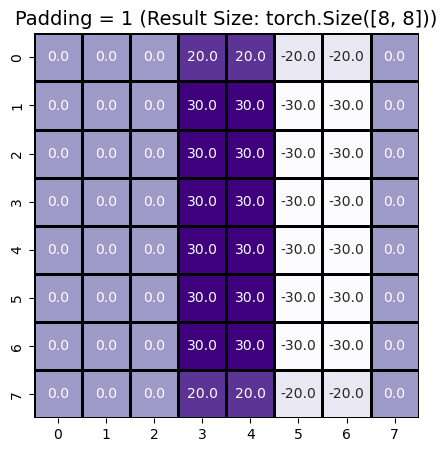

In [15]:
# Padding = 1
out_padding = F.conv2d(input_batch, kernel_batch, stride=1, padding=1)

plot_matrix(out_padding, title=f"Padding = 1 (Result Size: {out_padding.shape[-2:]})", cmap="Purples")

## 3. How ConvNets Learn: Gradient Accumulation 🧠

This is the most critical part of training. 

When we train a network, we update the weights (the Kernel numbers) to minimize error.
But a single number in the Kernel (e.g., the top-left weight) is used **many times** as it slides across the image.

**The Rule:** 
The gradient for a weight is the **SUM** of the gradients from all the places where that weight was used.

Let's simulate this "Backward Pass" manually.

In [16]:
# 1. Define a tiny input (3x3) and kernel (2x2)
tiny_input = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0]
], requires_grad=False).reshape(1, 1, 3, 3)

tiny_kernel = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0]
]).reshape(1, 1, 2, 2)

tiny_kernel.requires_grad = True # We want to learn this kernel

# 2. Forward Pass
output = F.conv2d(tiny_input, tiny_kernel, stride=1, padding=0)

print("Forward Output:\n", output.squeeze().detach().numpy())

# 3. Assume we have some error (Gradient from the next layer)
# Let's say the error at each position of the output is exactly 1.0
grad_output = torch.ones_like(output)

# 4. Backward Pass (PyTorch does the accumulation magic)
output.backward(grad_output)

print("\n--- GRADIENT ACCUMULATION ---")
print("Input Gradients for the Kernel (dLoss/dKernel):\n", tiny_kernel.grad.squeeze().numpy())

# 5. Manual Verification (Why are these the numbers?)
# The top-left weight of the kernel (w_00) touched:
# - Pixel (0,0)=1.0
# - Pixel (0,1)=2.0
# - Pixel (1,0)=4.0
# - Pixel (1,1)=5.0
# Sum = 1 + 2 + 4 + 5 = 12.0
print("\nManual Calculation for Top-Left Weight:")
print("Sum of inputs it touched: 1.0 + 2.0 + 4.0 + 5.0 = 12.0")
print("Matches PyTorch gradient?", tiny_kernel.grad[0,0,0,0].item() == 12.0)

Forward Output:
 [[ 6.  8.]
 [12. 14.]]

--- GRADIENT ACCUMULATION ---
Input Gradients for the Kernel (dLoss/dKernel):
 [[12. 16.]
 [24. 28.]]

Manual Calculation for Top-Left Weight:
Sum of inputs it touched: 1.0 + 2.0 + 4.0 + 5.0 = 12.0
Matches PyTorch gradient? True


**Conclusion:** The network learns "global" features because the error signals from the entire image are **accumulated** into the small shared kernel.

## 4. Real Image Filters (Visualizing Effects) 🖼️

Enough grids. Let's look at a real photo.
We will manually create standard computer vision filters and apply them to see what they extract.

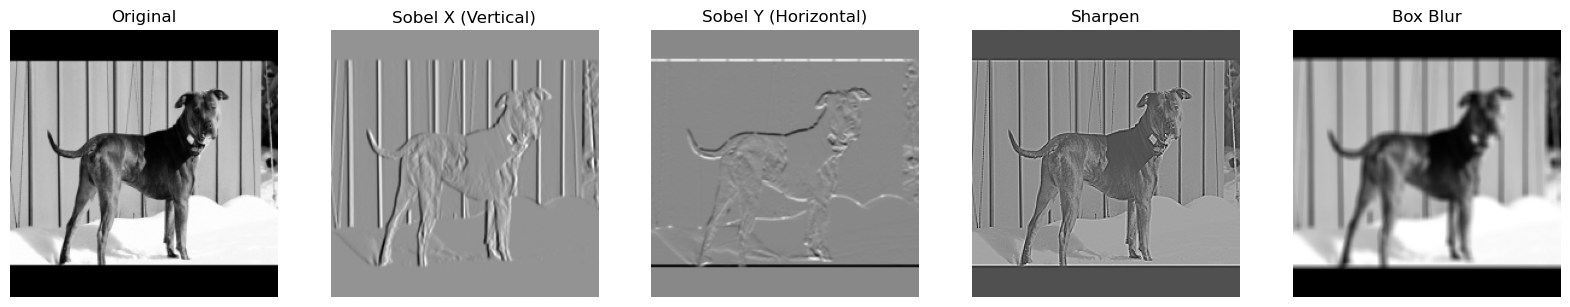

In [17]:
# Load a real image
try:
    dataset = torchvision.datasets.OxfordIIITPet(root='../Datasets', split='trainval', download=True)
except:
    dataset = torchvision.datasets.OxfordIIITPet(root='../Datasets', split='trainval', download=True)

image_pil, _ = dataset[110]

# Convert to Tensor and Grayscale for this demo
prep_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

img_tensor = prep_transform(image_pil).unsqueeze(0) # [1, 1, 224, 224]

# --- DEFINE FILTERS ---

# 1. Edge Detection (Sobel X - Vertical)
k_sobel_x = torch.tensor([
    [-1., 0., 1.],
    [-2., 0., 2.],
    [-1., 0., 1.]
]).reshape(1, 1, 3, 3)

# 2. Edge Detection (Sobel Y - Horizontal)
k_sobel_y = torch.tensor([
    [-1., -2., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  2.,  1.]
]).reshape(1, 1, 3, 3)

# 3. Sharpen
k_sharpen = torch.tensor([
    [ 0., -1.,  0.],
    [-1.,  5., -1.],
    [ 0., -1.,  0.]
]).reshape(1, 1, 3, 3)

# 4. Box Blur (Averaging)
k_blur = torch.ones((1, 1, 5, 5)) / 25.0 # 5x5 average

# Apply Convolutions
out_sobel_x = F.conv2d(img_tensor, k_sobel_x)
out_sobel_y = F.conv2d(img_tensor, k_sobel_y)
out_sharpen = F.conv2d(img_tensor, k_sharpen)
out_blur = F.conv2d(img_tensor, k_blur)

# Plotting
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
titles = ["Original", "Sobel X (Vertical)", "Sobel Y (Horizontal)", "Sharpen", "Box Blur"]
images = [img_tensor, out_sobel_x, out_sobel_y, out_sharpen, out_blur]

for i, ax in enumerate(axes):
    img_display = images[i].squeeze().numpy()
    ax.imshow(img_display, cmap='gray')
    ax.set_title(titles[i])
    ax.axis('off')

plt.show()

## 5. Spoiler: Color Convolutions (3 Channels) 🌈

So far, we worked with Grayscale (1 Channel).
But the world is colored. How does a CNN handle Red, Green, and Blue?

The Kernel is no longer 2D ($3 \times 3$). It becomes 3D ($3 \times 3 \times 3$).
* 3 Channels in the Input.
* 3 Channels in the Kernel (one for each color).

We do the math for Red, Green, and Blue separately, and then **Sum them up** to get a single number.

Let's see what happens when we apply a random filter to a color image.

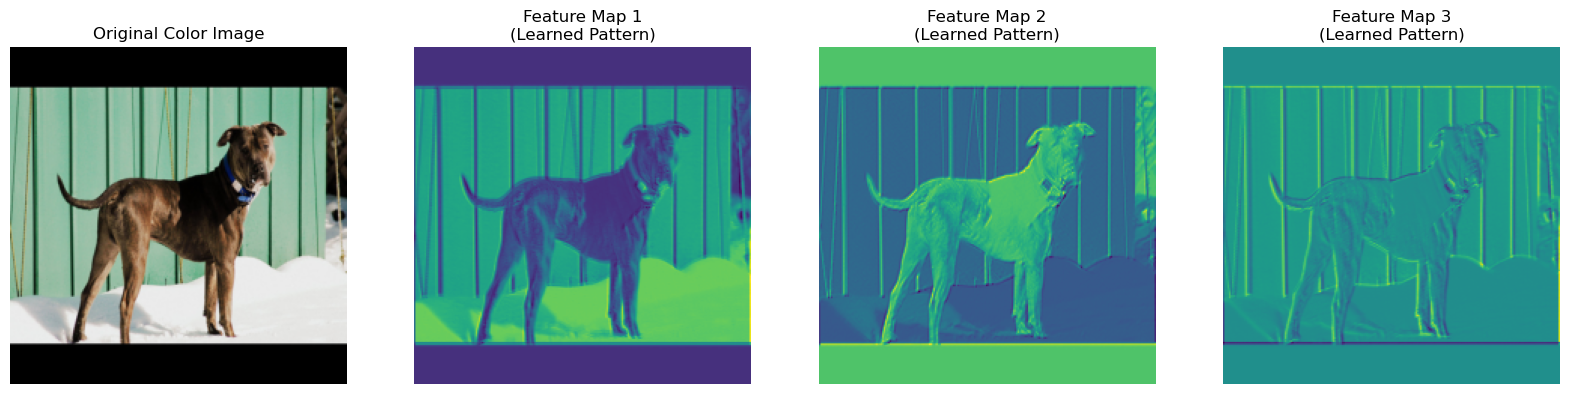

In [18]:
# Load Color Image
color_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
color_img = color_transform(image_pil).unsqueeze(0) # [1, 3, 224, 224]

# Create a Random Filter with 3 Input Channels
# We want to produce 3 Output Features (for visualization)
random_kernel = torch.randn(3, 3, 3, 3) # [Out=3, In=3, K=3, K=3]

color_output = F.conv2d(color_img, random_kernel, padding=1)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original
axes[0].imshow(color_img.squeeze().permute(1, 2, 0))
axes[0].set_title("Original Color Image")
axes[0].axis('off')

# 3 Feature Maps
for i in range(3):
    f_map = color_output[0, i].detach().numpy()
    axes[i+1].imshow(f_map, cmap='viridis')
    axes[i+1].set_title(f"Feature Map {i+1}\n(Learned Pattern)")
    axes[i+1].axis('off')

plt.show()

### Summary

You have now seen the inner workings of a CNN:
1.  **Convolution** is just sliding a window and summing numbers.
2.  **Filters** detect patterns (lines, edges).
3.  **Stride & Padding** control the output size.
4.  **Training** works by summing up errors from every position the filter touched.
5.  **Color** adds depth ($3 \times K \times K$), but the math remains the same.